# Notebook 04: Regional Sales Clustering

## Objective

This notebook examines whether video games can be grouped into meaningful clusters based on their regional sales patterns.

Rather than clustering games using raw regional sales totals, each region's sales are divided by global sales to create regional sales proportions. This allows games with very different total sales to be compared based on where their sales were concentrated.

K-means clustering is used to identify groups of games with similar sales distributions across:

- North America
- Europe
- Japan

The elbow method is first used to select an appropriate number of clusters. The resulting clusters are then interpreted using their average regional sales proportions and genre distributions.

## Research Question

**Can video games be grouped into clusters based on attributes in the dataset, and what patterns emerge from these clusters?**

## Notebook Structure

1. Load and validate the cleaned dataset
2. Prepare regional sales proportions
3. Standardize the clustering features
4. Select the number of clusters using the elbow method
5. Apply K-means clustering
6. Examine regional patterns within each cluster
7. Examine genre distributions within each cluster
8. Interpret the resulting clusters

In [38]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [40]:
data_path = Path("../../data/processed/video_game_sales_cleaned.csv")

df = pd.read_csv(data_path)

df.head()

,name,platform,year,genre,publisher,na_sales,eu_sales,jp_sales,other_sales,global_sales,regional_sales_total,decade,sales_tier,is_high_seller,na_sales_share,eu_sales_share,jp_sales_share,other_sales_share,dominant_region
0,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,82.74,2000s,blockbuster,1,0.501450,0.350737,0.045564,0.102248,North America
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,40.24,1980s,blockbuster,1,0.722664,0.088966,0.169235,0.019135,North America
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82,35.83,2000s,blockbuster,1,0.442367,0.359475,0.105777,0.092381,North America
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00,33.00,2000s,blockbuster,1,0.477273,0.333636,0.099394,0.089697,North America
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,31.38,1990s,blockbuster,1,0.359146,0.283301,0.325685,0.031867,North America


In [42]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 16,287
Columns: 19


In [43]:
required_columns = [
    "name",
    "genre",
    "na_sales",
    "eu_sales",
    "jp_sales",
    "global_sales"
]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

print("All required columns are available.")

All required columns are available.


In [44]:
df[required_columns].info()

<class 'pandas.DataFrame'>
RangeIndex: 16287 entries, 0 to 16286
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          16287 non-null  str    
 1   genre         16287 non-null  str    
 2   na_sales      16287 non-null  float64
 3   eu_sales      16287 non-null  float64
 4   jp_sales      16287 non-null  float64
 5   global_sales  16287 non-null  float64
dtypes: float64(4), str(2)
memory usage: 763.6 KB


## Prepare the Clustering Data

The clustering model uses three regional sales proportions:

- `na_ratio`: North American sales divided by global sales
- `eu_ratio`: European sales divided by global sales
- `jp_ratio`: Japanese sales divided by global sales

Using proportions prevents games with very high global sales from dominating the clustering solely because of their commercial scale.

Games with zero global sales are excluded because their regional sales proportions cannot be calculated.

In [45]:
cluster_df = df[
    [
        "name",
        "genre",
        "na_sales",
        "eu_sales",
        "jp_sales",
        "global_sales"
    ]
].copy()

rows_before = len(cluster_df)

cluster_df = cluster_df.dropna(
    subset=[
        "genre",
        "na_sales",
        "eu_sales",
        "jp_sales",
        "global_sales"
    ]
)

cluster_df = cluster_df[
    cluster_df["global_sales"] > 0
].copy()

rows_after = len(cluster_df)

print(f"Rows before filtering: {rows_before:,}")
print(f"Rows after filtering: {rows_after:,}")
print(f"Rows removed: {rows_before - rows_after:,}")

Rows before filtering: 16,287
Rows after filtering: 16,287
Rows removed: 0


In [46]:
cluster_df["na_ratio"] = (
    cluster_df["na_sales"]
    / cluster_df["global_sales"]
)

cluster_df["eu_ratio"] = (
    cluster_df["eu_sales"]
    / cluster_df["global_sales"]
)

cluster_df["jp_ratio"] = (
    cluster_df["jp_sales"]
    / cluster_df["global_sales"]
)

cluster_df[
    [
        "name",
        "na_ratio",
        "eu_ratio",
        "jp_ratio"
    ]
].head()

,name,na_ratio,eu_ratio,jp_ratio
0,Wii Sports,0.501450,0.350737,0.045564
1,Super Mario Bros.,0.722664,0.088966,0.169235
2,Mario Kart Wii,0.442490,0.359576,0.105807
3,Wii Sports Resort,0.477273,0.333636,0.099394
4,Pokemon Red/Pokemon Blue,0.359260,0.283392,0.325789


In [47]:
ratio_columns = [
    "na_ratio",
    "eu_ratio",
    "jp_ratio"
]

cluster_df[ratio_columns].describe().round(3)

,na_ratio,eu_ratio,jp_ratio
count,16287.000,16287.000,16287.000
mean,0.454,0.229,0.244
std,0.340,0.249,0.402
min,0.000,0.000,0.000
25%,0.000,0.000,0.000
50%,0.500,0.200,0.000
75%,0.750,0.375,0.364
max,1.000,1.000,1.000


## Standardize the Clustering Features

The regional sales proportions are standardized before applying K-means.

Standardization transforms each feature so that it has a mean of approximately zero and a standard deviation of approximately one. This matches the preprocessing used in the original analysis and ensures that differences in feature variation do not cause one region to have greater influence on the distance calculations.

In [48]:
clustering_features = cluster_df[
    [
        "na_ratio",
        "eu_ratio",
        "jp_ratio"
    ]
].copy()

scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    clustering_features
)

scaled_features_df = pd.DataFrame(
    scaled_features,
    columns=clustering_features.columns,
    index=clustering_features.index
)

scaled_features_df.describe().round(3)

,na_ratio,eu_ratio,jp_ratio
count,16287.000,16287.000,16287.000
mean,-0.000,0.000,0.000
std,1.000,1.000,1.000
min,-1.334,-0.920,-0.606
25%,-1.334,-0.920,-0.606
50%,0.135,-0.117,-0.606
75%,0.870,0.586,0.297
max,1.605,3.098,1.879


## Select the Number of Clusters

The elbow method is used to determine an appropriate number of clusters.

For each possible value of \(k\), K-means calculates inertia, which represents the total squared distance between the observations and their assigned cluster centres. Inertia decreases as the number of clusters increases.

The selected value should occur near the point where adding more clusters begins to produce substantially smaller improvements.

In [49]:
inertia = []

k_values = range(1, 11)

for k in k_values:
    elbow_model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    elbow_model.fit(scaled_features)
    inertia.append(elbow_model.inertia_)

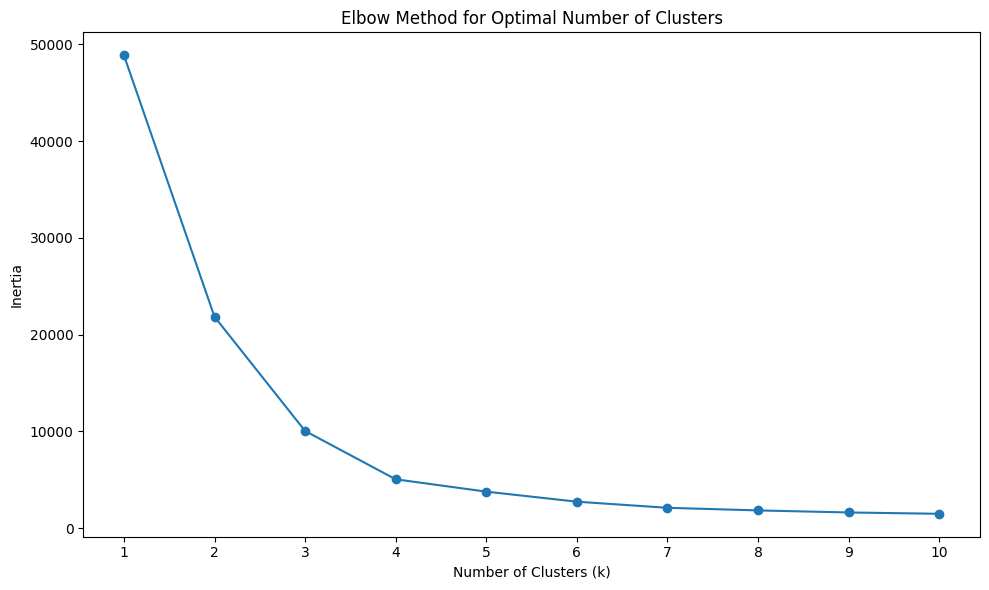

In [50]:
plt.figure(figsize=(10, 6))

plt.plot(
    list(k_values),
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))

plt.tight_layout()
plt.show()

**Key takeaway:** The largest reductions in inertia occur before three clusters. After \(k = 3\), the curve begins to flatten and each additional cluster produces a smaller improvement. Therefore, three clusters are selected for the final K-means model.

## Apply K-Means Clustering

The final K-means model is fitted using three clusters, matching the result of the elbow method.

In [51]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_df["original_cluster"] = (
    kmeans.fit_predict(scaled_features)
)

cluster_df[
    [
        "name",
        "genre",
        "na_ratio",
        "eu_ratio",
        "jp_ratio",
        "original_cluster"
    ]
].head(10)

,name,genre,na_ratio,eu_ratio,jp_ratio,original_cluster
0,Wii Sports,Sports,0.501450,0.350737,0.045564,1
1,Super Mario Bros.,Platform,0.722664,0.088966,0.169235,0
2,Mario Kart Wii,Racing,0.442490,0.359576,0.105807,1
3,Wii Sports Resort,Sports,0.477273,0.333636,0.099394,1
4,Pokemon Red/Pokemon Blue,Role-Playing,0.359260,0.283392,0.325789,1
5,Tetris,Puzzle,0.766689,0.074686,0.139458,0
6,New Super Mario Bros.,Platform,0.379207,0.307564,0.216594,1
7,Wii Play,Misc,0.483460,0.317023,0.100965,1
8,New Super Mario Bros. Wii,Platform,0.509783,0.246681,0.164221,0
9,Duck Hunt,Shooter,0.951254,0.022254,0.009890,0


In [52]:
original_cluster_summary = (
    cluster_df
    .groupby("original_cluster")[
        [
            "na_ratio",
            "eu_ratio",
            "jp_ratio"
        ]
    ]
    .mean()
    .round(3)
)

original_cluster_summary

,na_ratio,eu_ratio,jp_ratio
original_cluster,,,
0,0.774,0.127,0.028
1,0.350,0.503,0.029
2,0.024,0.012,0.953


### Standardizing the Cluster Labels

K-means cluster numbers are arbitrary. For example, the Japan-dominant group may be labelled Cluster 1 during one run and Cluster 2 during another run even when the underlying groups are effectively the same.

To keep the notebook consistent with the original project, the clusters are relabelled according to their dominant regional pattern:

- Cluster 0: North America-dominant
- Cluster 1: Japan-dominant
- Cluster 2: Europe-oriented Western

In [54]:
na_cluster = (
    original_cluster_summary["na_ratio"].idxmax()
)

jp_cluster = (
    original_cluster_summary["jp_ratio"].idxmax()
)

remaining_clusters = [
    cluster
    for cluster in original_cluster_summary.index
    if cluster not in [na_cluster, jp_cluster]
]

if len(remaining_clusters) != 1:
    raise ValueError(
        "The cluster patterns could not be uniquely identified."
    )

western_cluster = remaining_clusters[0]

cluster_remap = {
    na_cluster: 0,
    jp_cluster: 1,
    western_cluster: 2
}

cluster_df["cluster"] = (
    cluster_df["original_cluster"]
    .map(cluster_remap)
)

cluster_remap

{np.int32(0): 0, np.int32(2): 1, 1: 2}

In [55]:
cluster_name_map = {
    0: "North America-dominant",
    1: "Japan-dominant",
    2: "Europe-oriented Western"
}

cluster_df["cluster_name"] = (
    cluster_df["cluster"]
    .map(cluster_name_map)
)

cluster_df[
    [
        "name",
        "genre",
        "cluster",
        "cluster_name"
    ]
].head()

,name,genre,cluster,cluster_name
0,Wii Sports,Sports,2,Europe-oriented Western
1,Super Mario Bros.,Platform,0,North America-dominant
2,Mario Kart Wii,Racing,2,Europe-oriented Western
3,Wii Sports Resort,Sports,2,Europe-oriented Western
4,Pokemon Red/Pokemon Blue,Role-Playing,2,Europe-oriented Western


In [56]:
cluster_sizes = (
    cluster_df["cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("cluster")
    .reset_index(name="game_count")
)

cluster_sizes["cluster_name"] = (
    cluster_sizes["cluster"]
    .map(cluster_name_map)
)

cluster_sizes

,cluster,game_count,cluster_name
0,0,6915,North America-dominant
1,1,3796,Japan-dominant
2,2,5576,Europe-oriented Western


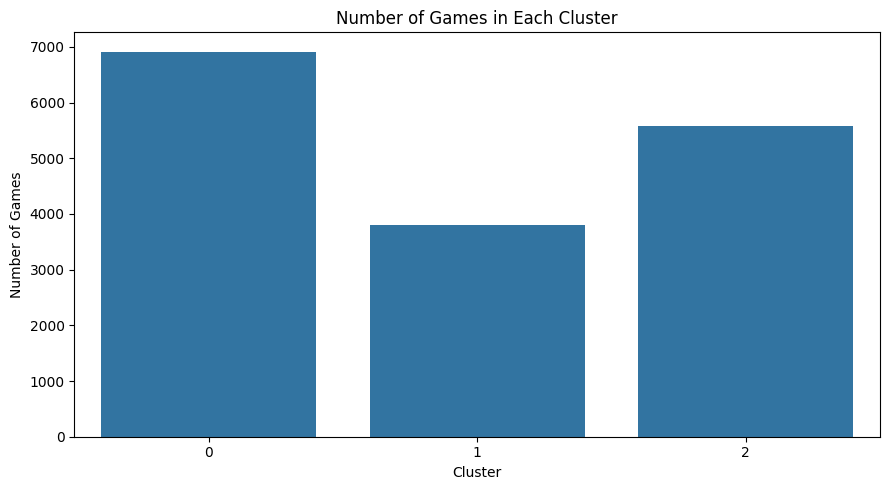

In [57]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=cluster_sizes,
    x="cluster",
    y="game_count"
)

plt.title("Number of Games in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Games")

plt.tight_layout()
plt.show()

**Key takeaway:** The clusters contain different numbers of games, meaning that some regional sales patterns occur more frequently in the dataset than others. These size differences should be considered when comparing raw genre counts across the groups.

## Average Regional Sales Patterns

The average regional sales proportions are calculated for each cluster to determine the market pattern represented by each group.

In [58]:
cluster_summary = (
    cluster_df
    .groupby("cluster")[
        [
            "na_ratio",
            "eu_ratio",
            "jp_ratio"
        ]
    ]
    .mean()
    .round(3)
)

cluster_summary

,na_ratio,eu_ratio,jp_ratio
cluster,,,
0,0.774,0.127,0.028
1,0.024,0.012,0.953
2,0.350,0.503,0.029


In [59]:
cluster_profile = (
    cluster_summary
    .reset_index()
)

cluster_profile["cluster_name"] = (
    cluster_profile["cluster"]
    .map(cluster_name_map)
)

cluster_profile[
    [
        "cluster",
        "cluster_name",
        "na_ratio",
        "eu_ratio",
        "jp_ratio"
    ]
]

,cluster,cluster_name,na_ratio,eu_ratio,jp_ratio
0,0,North America-dominant,0.774,0.127,0.028
1,1,Japan-dominant,0.024,0.012,0.953
2,2,Europe-oriented Western,0.350,0.503,0.029


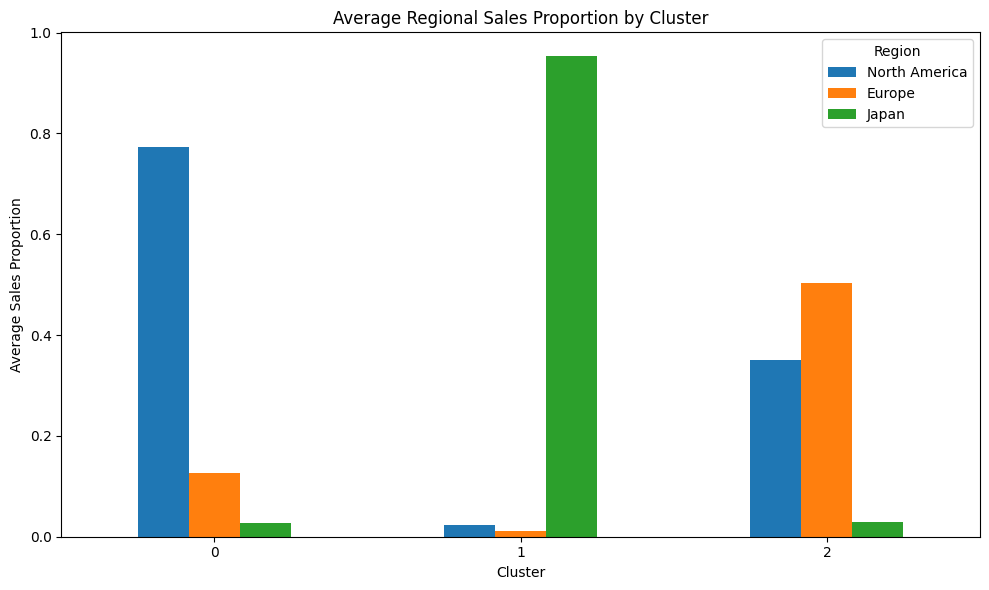

In [60]:
cluster_summary_plot = cluster_summary.rename(
    columns={
        "na_ratio": "North America",
        "eu_ratio": "Europe",
        "jp_ratio": "Japan"
    }
)

cluster_summary_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average Regional Sales Proportion by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Sales Proportion")
plt.xticks(rotation=0)
plt.legend(title="Region")

plt.tight_layout()
plt.show()

**Key takeaway:** The clustering identifies three distinct regional sales patterns. Cluster 0 is heavily dominated by North American sales, Cluster 1 is overwhelmingly dominated by Japanese sales, and Cluster 2 has a more balanced distribution between North America and Europe, with Europe contributing the largest average share.

## Genre Distribution Across Clusters

The cluster labels are applied to the original game records so that genre distributions can be examined within each regional sales group.

This helps determine whether the identified geographic sales patterns are associated with differences in the types of games represented in each cluster.

In [61]:
genre_cluster_counts = (
    cluster_df
    .groupby(
        [
            "cluster",
            "genre"
        ]
    )
    .size()
    .unstack(fill_value=0)
)

genre_cluster_counts

genre,Action,Adventure,Fighting,Misc,Platform,Puzzle,Racing,Role-Playing,Shooter,Simulation,Sports,Strategy
cluster,,,,,,,,,,,,
0,1370,316,329,811,506,329,578,404,588,381,1127,176
1,618,664,281,427,81,93,64,692,98,180,377,221
2,1262,294,226,448,288,148,583,372,596,286,800,273


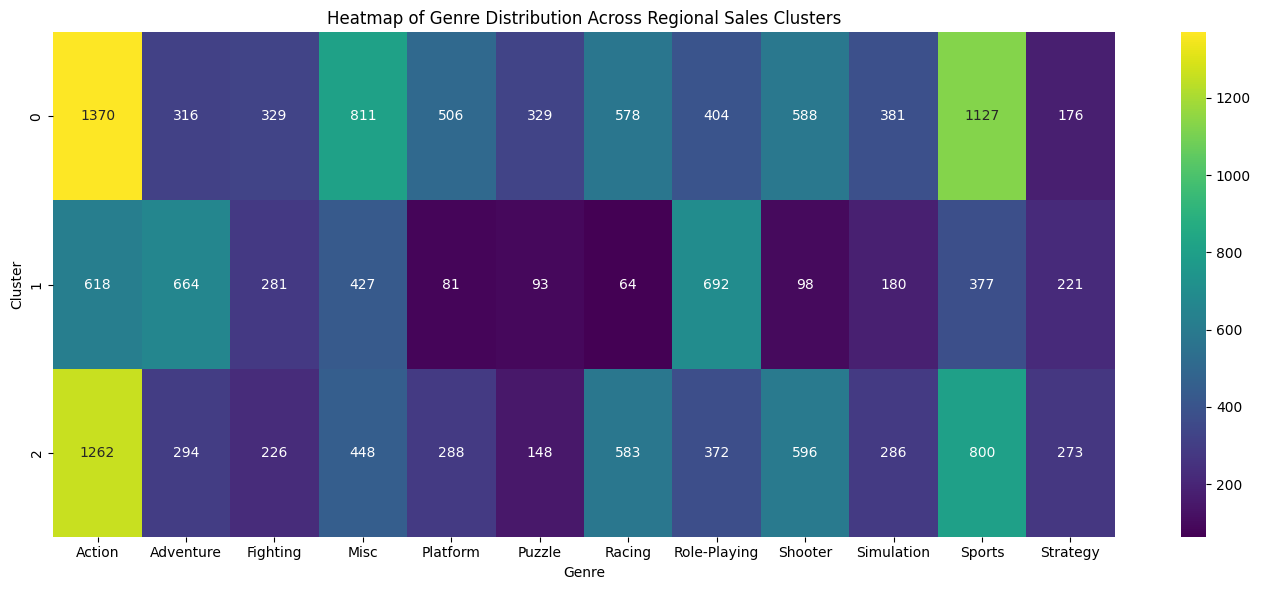

In [62]:
plt.figure(figsize=(14, 6))

sns.heatmap(
    genre_cluster_counts,
    annot=True,
    fmt="d",
    cmap="viridis"
)

plt.title(
    "Heatmap of Genre Distribution Across Regional Sales Clusters"
)
plt.xlabel("Genre")
plt.ylabel("Cluster")

plt.tight_layout()
plt.show()

**Key takeaway:** Action and Sports games are especially common in the North America-dominant and Europe-oriented clusters. The Japan-dominant cluster contains a stronger concentration of Role-Playing and Adventure games, indicating that the regional sales groups are also associated with differences in genre composition.

In [63]:
top_genres_by_cluster = []

for cluster in genre_cluster_counts.index:
    cluster_top_genres = (
        genre_cluster_counts
        .loc[cluster]
        .sort_values(ascending=False)
        .head(5)
        .reset_index()
    )

    cluster_top_genres.columns = [
        "genre",
        "game_count"
    ]

    cluster_top_genres["cluster"] = cluster
    cluster_top_genres["cluster_name"] = (
        cluster_name_map[cluster]
    )

    top_genres_by_cluster.append(
        cluster_top_genres
    )

top_genres_by_cluster = pd.concat(
    top_genres_by_cluster,
    ignore_index=True
)

top_genres_by_cluster[
    [
        "cluster",
        "cluster_name",
        "genre",
        "game_count"
    ]
]

,cluster,cluster_name,genre,game_count
0,0,North America-dominant,Action,1370
1,0,North America-dominant,Sports,1127
2,0,North America-dominant,Misc,811
3,0,North America-dominant,Shooter,588
4,0,North America-dominant,Racing,578
5,1,Japan-dominant,Role-Playing,692
6,1,Japan-dominant,Adventure,664
7,1,Japan-dominant,Action,618
8,1,Japan-dominant,Misc,427
9,1,Japan-dominant,Sports,377


## Interpretation

The K-means analysis shows that video games can be grouped into meaningful clusters based on the regional distribution of their sales.

The elbow method showed a clear bend around three clusters. The reductions in inertia became smaller after this point, supporting the use of three groups for the final model.

Cluster 0 was dominated by North American sales, with a much smaller contribution from Europe and minimal influence from Japan. Action and Sports were the most prominent genres in this cluster, indicating that these genres were strongly represented among games whose sales were concentrated in North America.

Cluster 1 was overwhelmingly dominated by Japanese sales and received minimal contributions from North America and Europe. Role-Playing and Adventure games had a stronger presence in this group, revealing a clear connection between Japanese market concentration and genre composition.

Cluster 2 represented a more balanced distribution between North America and Europe, although Europe contributed the largest average proportion. Action and Sports were also prominent within this cluster, indicating that these genres performed across both major Western markets even though their regional sales distributions differed.

Overall, the results show that video games can be grouped into distinct and interpretable clusters based on regional sales proportions. Each cluster represents a different market pattern, and the genre heatmap demonstrates that these regional patterns are connected to differences in genre composition. This supports the conclusion that regional market preferences play an important role in shaping video game sales.